In [140]:
# Compute vertical velocities for MPAS and LFRic in the gap and vortex cases

In [141]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [142]:
# Function to remove a contour,
# courtesy of tomplot:
# https://github.com/tommbendall/tomplot

def remove_colour(old_cmap, level_to_remove, num_levels):
    """
    Replaces two colours in a colour map with a shared colour, in effect
    removing a contour from the colour map.

    Args:
        old_cmap (`matplotlib.Colormap`): a colour map object
        level_to_remove (int): the index of the contour to be removed
        num_levels(int): the total number of contour levels

    Returns:
        `matplotlib.Colormap`: a new colour map.
    """

    newcolours = old_cmap(np.linspace(0, 1.0, num_levels-1))
    merged_colour = old_cmap(level_to_remove/num_levels)
    newcolours[level_to_remove-1] = merged_colour
    newcolours[level_to_remove] = merged_colour
    new_cmap = ListedColormap(newcolours)

    return new_cmap

In [143]:
def compute_P_levels(p0, ps):
    # Compute the p levels in a hybrid model.
    # Hard code the coefficients here:
    lev = 56
    ilev = 57

    hyai = np.array([0.09050670980690104, 0.08995635981437577, 0.08937238067306334, 0.08875271747306365, 0.08809518973916056, 0.08739748375815026, 0.08665714443733119, 0.08587156666550647, 0.08503798614610039, 0.08415346967013226, 0.08321490479482004, 0.08221898889149477, 0.08116221752428777, 0.08004087211869704, 0.07885100687664118, 0.07758843489195744, 0.07624871341748701, 0.07482712823190504, 0.07331867705128559, 0.0717180519270299, 0.07001962056821956, 0.06821740652267175, 0.0663050681469573, 0.06427587629138137, 0.06212269062140435, 0.05983793449218211, 0.05741356828781585, 0.05484106113149445, 0.05211136086698559, 0.04921486220584492, 0.04614137292825965, 0.04288007801859395, 0.039478344424962786, 0.036295676722387205, 0.03332940558992792, 0.030573339223869955, 0.02801882331670602, 0.025655591039917103, 0.02347242775851588, 0.021457678362589494, 0.019599624710769814, 0.017886758358974353, 0.016307970549427342, 0.014852678008666409, 0.013510899819456301, 0.012273297678638384, 0.011131189305746858, 0.010076542633771557, 0.009009311071453197, 0.007929344445782083, 0.0068364907917635165, 0.005730596331034787, 0.00461150545022615, 0.0034790606790643386, 0.002333102668214404, 0.0011734701668573155, 0.0])
    hybi = np.array([0.0, 0.006080764549937297, 0.012533094355742546, 0.019379693920810688, 0.026644655107732278, 0.03435354191290797, 0.04253348042131927, 0.051213254257985986, 0.06042340587198839, 0.07019634400945093, 0.0805664577536661, 0.09157023753364128, 0.10324640352687701, 0.11563604190819884, 0.12878274942407789, 0.14273278680116816, 0.15753524152887585, 0.17324220058876183, 0.18990893373857776, 0.20759408799587725, 0.22635989400555315, 0.2462723850174671, 0.2674016292447125, 0.2898219764201347, 0.3136123194186923, 0.3388563718662595, 0.3656429627117196, 0.39406634879889413, 0.4242265465381863, 0.45622968384502727, 0.49018837358353046, 0.5262221098294266, 0.5638075396930111, 0.5989725314308167, 0.631746578115178, 0.6621980923944852, 0.6904226948865437, 0.716533822799943, 0.7406553855664949, 0.76291615938343, 0.7834456168765139, 0.8023709137462146, 0.8198147895971367, 0.8358941780078512, 0.8507193571804534, 0.8643935051354327, 0.8770125515611428, 0.8886652419995137, 0.9004569816903645, 0.9123894298809492, 0.924464265617992, 0.9366831879839495, 0.9490479163360934, 0.9615601905484469, 0.9742217712566049, 0.9870344401054797, 1.0])
    
    hyam = np.array([0.0902315348106384, 0.08966437024371957, 0.08906254907306349, 0.0884239536061121, 0.08774633674865541, 0.08702731409774073, 0.08626435555141883, 0.08545477640580343, 0.08459572790811633, 0.08368418723247614, 0.0827169468431574, 0.08169060320789127, 0.0806015448214924, 0.07944593949766911, 0.0782197208842993, 0.07691857415472222, 0.07553792082469603, 0.07407290264159531, 0.07251836448915774, 0.07086883624762473, 0.06911851354544565, 0.06726123733481452, 0.06529047221916934, 0.06319928345639286, 0.06098031255679323, 0.05862575138999898, 0.05612731470965515, 0.05347621099924002, 0.050663111536415256, 0.047678117567052286, 0.0445107254734268, 0.04117921122177837, 0.037887010573674995, 0.03481254115615756, 0.03195137240689894, 0.029296081270287988, 0.026837207178311562, 0.02456400939921649, 0.022465053060552687, 0.020528651536679654, 0.018743191534872083, 0.017097364454200847, 0.015580324279046875, 0.014181788914061355, 0.012892098749047343, 0.011702243492192621, 0.010603865969759207, 0.009542926852612377, 0.00846932775861764, 0.0073829176187728, 0.006283543561399152, 0.005171050890630469, 0.004045283064645244, 0.0029060816736393713, 0.0017532864175358598, 0.0005867350834286578])
    hybm = np.array([0.0030403822749686484, 0.009306929452839922, 0.015956394138276618, 0.023012174514271483, 0.030499098510320125, 0.03844351116711362, 0.046873367339652625, 0.05581833006498719, 0.06530987494071966, 0.07538140088155851, 0.08606834764365369, 0.09740832053025915, 0.10944122271753792, 0.12220939566613837, 0.13575776811262302, 0.150134014165022, 0.16538872105881885, 0.1815755671636698, 0.1987515108672275, 0.2169769910007152, 0.23631613951151012, 0.2568370071310898, 0.2786118028324236, 0.3017171479194135, 0.3262343456424759, 0.35224966728898954, 0.37985465575530686, 0.40914644766854025, 0.44022811519160676, 0.47320902871427883, 0.5082052417064785, 0.5450148247612189, 0.5813900355619139, 0.6153595547729973, 0.6469723352548316, 0.6763103936405145, 0.7034782588432433, 0.728594604183219, 0.7517857724749625, 0.773180888129972, 0.7929082653113643, 0.8110928516716757, 0.8278544838024939, 0.8433067675941524, 0.8575564311579431, 0.8707030283482877, 0.8828388967803282, 0.894561111844939, 0.9064232057856568, 0.9184268477494706, 0.9305737268009707, 0.9428655521600214, 0.9553040534422701, 0.9678909809025259, 0.9806281056810423, 0.9935172200527398])

    p_vals = np.zeros((ilev,len(ps)))

    for k in np.arange(ilev):
        #p_vals[int((ilev-k)%ilev),:] = hyai[k]*p0 + hybi[k]*ps
        p_vals[k,:] = hyai[k]*p0 + hybi[k]*ps
                      
    return p_vals

In [144]:
# Choose the test case and model
test = 'gap'
model = 'MPAS'

In [145]:
# Test case parameters
z_T = 20e3
u0 = 10
X = 20
a = 6371229/X
lambda_c = np.pi

In [146]:
# Create the stretched grid:
z_vals_i = [0]
geo_fact = 1.01679

while z_vals_i[-1] < 1000:
    z_vals_i.append(z_vals_i[-1] + 100)

while z_vals_i[-1] < 6000:
    z_vals_i.append(z_vals_i[-1] + min((z_vals_i[-1]-z_vals_i[-2])**geo_fact, 500))

while z_vals_i[-1] < 20000:
    z_vals_i.append(z_vals_i[-1] + 500)

z_vals_i = np.asarray(z_vals_i)

#Verify the values are as expected
print(z_vals_i)
print(f' \n There are {len(z_vals_i) - 1} midpoint levels')

[    0.           100.           200.           300.
   400.           500.           600.           700.
   800.           900.          1000.          1108.03886175
  1224.91444958  1351.51654416  1488.83878241  1637.99231466
  1800.22144869  1976.92159672  2169.6598954   2380.19893339
  2610.52409741  2862.87513865  3139.78266924  3444.11042785
  3779.10430735  4148.44932204  4556.33591337  5007.53725856
  5507.4995669   6007.4995669   6507.4995669   7007.4995669
  7507.4995669   8007.4995669   8507.4995669   9007.4995669
  9507.4995669  10007.4995669  10507.4995669  11007.4995669
 11507.4995669  12007.4995669  12507.4995669  13007.4995669
 13507.4995669  14007.4995669  14507.4995669  15007.4995669
 15507.4995669  16007.4995669  16507.4995669  17007.4995669
 17507.4995669  18007.4995669  18507.4995669  19007.4995669
 19507.4995669  20007.4995669 ]
 
 There are 57 midpoint levels


In [147]:
# Convert to midpoint levels:
z_vals_m = np.zeros(len(z_vals_i)-1)
for i in np.arange(len(z_vals_m)):
    z_vals_m[i] = 0.5*(z_vals_i[i+1] + z_vals_i[i])

print(z_vals_m)

[   50.           150.           250.           350.
   450.           550.           650.           750.
   850.           950.          1054.01943087  1166.47665567
  1288.21549687  1420.17766328  1563.41554853  1719.10688167
  1888.5715227   2073.29074606  2274.92941439  2495.3615154
  2736.69961803  3001.32890395  3291.94654855  3611.6073676
  3963.7768147   4352.39261771  4781.93658596  5257.51841273
  5757.4995669   6257.4995669   6757.4995669   7257.4995669
  7757.4995669   8257.4995669   8757.4995669   9257.4995669
  9757.4995669  10257.4995669  10757.4995669  11257.4995669
 11757.4995669  12257.4995669  12757.4995669  13257.4995669
 13757.4995669  14257.4995669  14757.4995669  15257.4995669
 15757.4995669  16257.4995669  16757.4995669  17257.4995669
 17757.4995669  18257.4995669  18757.4995669  19257.4995669
 19757.4995669 ]


In [148]:
# Lon-lat grid, at 0.5 degree resolution
lon = np.linspace(0., 360., 720, endpoint=False)
lat = np.linspace(-90., 90., 361)

LON_DEG, LAT_DEG = np.meshgrid(lon, lat)

# Cropped for the mountain case
if test == 'gap':
    lat_crop_up = 40.
    lat_cent_down = -40.
    lon_crop_left = 140.
    lon_crop_right = 220.

    lon_ticks = np.linspace(140, 220, 5)
    lat_ticks = np.linspace(-40, 40, 5)
elif test == 'vortex':
    lat_crop_up = 40.
    lat_cent_down = 0.
    lon_crop_left = 160.
    lon_crop_right = 200.    

    lon_ticks = np.linspace(160, 200, 5)
    lat_ticks = np.linspace(0, 40, 5)



lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON_CROP, LAT_CROP = np.meshgrid(lon_crop, lat_crop)

deg2rad = np.pi/180
lon_rad = lon*deg2rad
lat_rad = lat*deg2rad
LON_RAD, LAT_RAD = np.meshgrid(lon_rad, lat_rad)

In [149]:
# Specific
if test == 'gap':
    h0 = 1500
    phi_c = 0.
    
    e1 = 10
    e2 = 10
    e3 = 10
    
    xlon = 40e3
    xlat = 300e3
    xgap = 50e3

    d1 = (xlon/2/a)*(np.log(10))**(-1/e1)
    d2 = (xlat/2/a)*(np.log(10))**(-1/e2)
    d3 = (xgap/2/a)*(np.log(10))**(-1/e3)

    fact1 = ((LON_RAD - lambda_c)/d1)**e1
    fact2 = ((LAT_RAD - phi_c)/d2)**e2
    fact3 = ((LAT_RAD - phi_c)/d3)**e3
    
    zs = h0*np.exp(-fact1-fact2)*(1-np.exp(-fact3))
    
    dzs_dlam = -(e1/d1) * ( ((LON_RAD - lambda_c)/d1)**(e1-1) ) * zs
    #dzs_dlam = -(e1/d1) * ( ( np.abs(LON_RAD - lambda_c)/d1)**(e1-1) ) * zs
elif test == 'vortex':
    h0 = 2000
    d = 12.5e3
    phi_c = np.pi/9.
    r = a*np.arccos(np.sin(phi_c)*np.sin(LAT_RAD) + np.cos(phi_c)*np.cos(LAT_RAD)*np.cos(LON_RAD - lambda_c))

    denom = np.sqrt(1-np.cos(r/a)**2)
    dr_dlam = a*np.sin(LON_RAD - lambda_c)*np.cos(phi_c)*np.cos(LAT_RAD)/denom
    zs = h0 * np.exp(-(r/d)**2)

    dzs_dlam = -(2*r/(d**2))*dr_dlam*zs
    
    quant = 1-np.cos(r/a)**2
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if quant[i,j] < 1e-5:
                print(f'too small, inds of {i,j}')
                print(f'{quant[i,j]} \n')
                dzs_dlam[i,j] = 0

    # Set NaN to zero
    #dzs_dlam[np.where(np.isnan(dzs_dlam))] = 0

    #dzs_dlam = (2*r*a*zs/(d*d))*np.sin(LON_RAD-lambda_c)*np.cos(phi_c)*np.cos(LAT_RAD)*((1-np.cos(r/a)**2)**(-0.5))


1499.999524043453


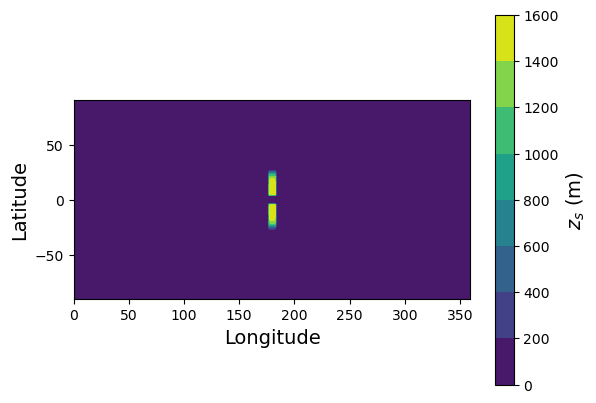

In [150]:
# Plot the surface topography to check
fig, ax = plt.subplots(1,1)
plot1 = ax.contourf(LON_DEG, LAT_DEG, zs)
cb = plt.colorbar(plot1)
ax.set_aspect('equal')
cb.set_label('$z_s$ (m)', size=14)
plt.xlabel('Longitude', size=14)
plt.ylabel('Latitude', size=14)

print(np.max(zs))

Maximum vertical velocity is 2.3430257234516185 m/s
Minimum vertical velocity is -2.3430257234514764 m/s


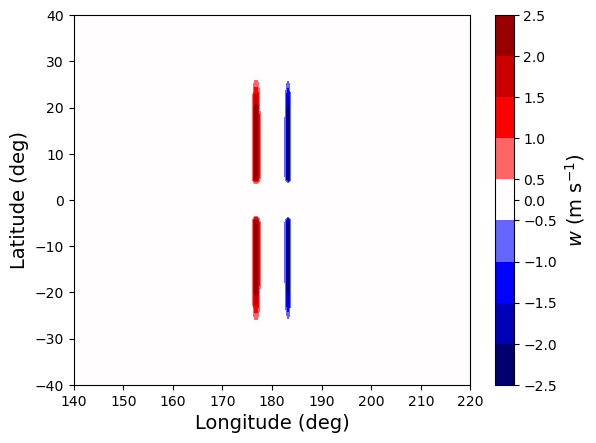

In [151]:
# Compute the vertical velocity, using
# w = u/(a cos(phi))* A * dzs_dlam,
# with u = u0 cos(phi), so this reduces to
# w = (u/a)* A * dzs_dlam
# As we plot at the surface, we have A = 1.

w_surf = (u0/a)*dzs_dlam

cmap = matplotlib.cm.seismic

if test == 'gap':
    contours = [-2.5, -2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2, 2.5] 
    cbar_ticks = [-2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5] 
elif test == 'vortex':
    contours = [-1.5, -1, -0.5, 0.5, 1, 1.5] 
    cbar_ticks = [-1.5, -1, -0.5, 0, 0.5, 1, 1.5]
    

# Plot! Visualise at the surface.
w_surf_crop = w_surf[lat_inds, :]
w_surf_crop = w_surf_crop[:, lon_inds]
plot = plt.contourf(LON_CROP, LAT_CROP, w_surf_crop, levels=contours, cmap=cmap)
cb = plt.colorbar(plot, ticks=cbar_ticks)

cb.set_label('$w$ (m s$^{-1}$)', size=14)
plt.xlabel('Longitude (deg)', size=14)
plt.ylabel('Latitude (deg)', size=14)

# Hmm, these appear to be quite large vertical velocities, so could make an important difference!
print(f'Maximum vertical velocity is {np.max(w_surf)} m/s')
print(f'Minimum vertical velocity is {np.min(w_surf)} m/s')

savefig = False

if savefig:
    if test == 'gap':
        plt.savefig('figures/nonhydro_W_gap_lon_lat')
    elif test == 'vortex':
        plt.savefig('figures/nonhydro_W_vortex_lon_lat')


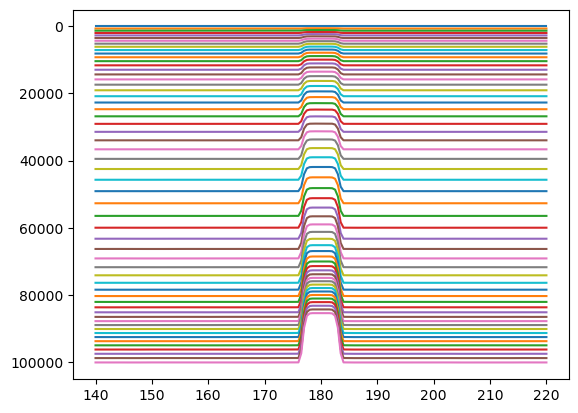

In [152]:
# Make the pressure levels and plot them to check
g = 9.80616
cp = 1004.64
Rd = 287.04
kappa = 2/7
p_sp = 100000
h0 = 1500
T0 = 288
u0 = 10
N2 = g**2/cp/T0

zs_crop = zs[lat_val, :]
zs_crop = zs_crop[lon_inds]

ps = p_sp*np.exp((-N2/g)*((u0**2)/(2*g)*(np.sin(lat_crop)**2 - 1) + zs_crop/kappa))
P_layers = compute_P_levels(1000, ps)

fig, ax = plt.subplots(1,1)
for i in np.arange(57):
    plt.plot(lon_crop, P_layers[i,:])

ax.invert_yaxis()

In [153]:
LONGC, LEV = np.meshgrid(lon_crop, z_vals_m) 

z_mpas = np.zeros_like(LEV)

for i in np.arange(57):
    z_mpas[i] = z_vals_m[i] + A

lat is 10.0 deg
(57, 161)
(57, 161)
(57, 161)
2.3426539881952095


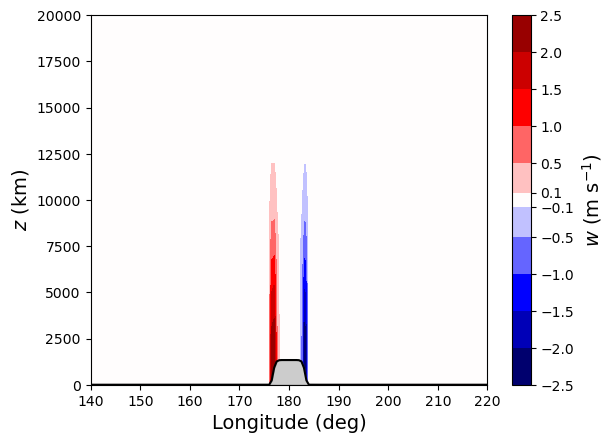

In [154]:
# What about in a cross-section?
LONGC, LEV = np.meshgrid(lon_crop, z_vals_m) 

# Pick the latitude to slice at:
if test == 'gap':
    # 10 deg
    lat_val = 200
elif test == 'vortex':
     # 20 deg
    lat_val = 220
print(f'lat is {lat[lat_val]} deg')

dzs_dlam_crop = dzs_dlam[lat_val, lon_inds]

vals = np.zeros((len(z_vals_m), len(lon_crop)))
z_mpas = np.zeros((len(z_vals_m), len(lon_crop)))

# Compute values at each A
# This is for MPAS:
for i in np.arange(len(z_vals_m)):
    z_bar = z_vals_m[i]
    A = np.cos(np.pi*z_bar/2./z_T)**6
    vals[i,:] = (u0/a)*A*dzs_dlam_crop
    z_mpas[i] = z_vals_m[i] + A*zs_crop

print(np.shape(LONGC))
print(np.shape(LEV))
print(np.shape(vals))

max_val = np.max(np.abs(vals))
print(max_val)

cmap = matplotlib.cm.seismic

if test == 'gap':
    contours = [-2.5, -2, -1.5, -1, -0.5, -0.1, 0.1, 0.5, 1, 1.5, 2, 2.5] 
    cbar_ticks = [-2.5, -2, -1.5, -1, -0.5, -0.1, 0.1, 0.5, 1, 1.5, 2, 2.5] 
elif test == 'vortex':
    contours = [-1.5, -1, -0.5, -0.1, 0.1, 0.5, 1, 1.5] 
    cbar_ticks = [-1.5, -1, -0.5, -0.1, 0.1, 0.5, 1, 1.5]

# Remove zero contour if desired
#level_to_remove = int(np.floor((len(contours) - 1) / 2))
#cmap = remove_colour(cmap, level_to_remove, len(contours))

plt.figure()
plt.contourf(LONGC, z_mpas, vals, cmap=cmap, levels=contours)
plt.xlabel('Longitude (deg)',size = 14)
plt.ylabel(r"$z$ (km)", size=14)

plt.plot(lon_crop, zs_crop, c='k')
plt.fill_between(lon_crop, zs_crop, color='grey', alpha=0.4)
plt.ylim([0,20000])

cb = plt.colorbar(ticks=cbar_ticks, spacing='proportional')
cb.set_label('$w$ (m s$^{-1}$)', size=14)

savefig = False

if savefig:
    if test == 'gap':
        plt.savefig('figures/nonhydro_W_gap_cross_section')
    elif test == 'vortex':
        plt.savefig('figures/nonhydro_W_vortex_cross_section')


In [ ]:
# Make these into a side-by-side figure. This is needed for GMD

w_surf_crop = w_surf[lat_inds, :]
w_surf_crop = w_surf_crop[:, lon_inds]

fig, axes = plt.subplots(1,2, figsize=(10,6), constrained_layout=True)
ax1, ax2 = axes

plot1 = ax1.contourf(LON_CROP, LAT_CROP, w_surf_crop, levels=contours, cmap=cmap)
ax1.set_xlabel('Longitude (deg)', size=14)
ax1.set_ylabel('Latitude (deg)', size=14)
ax1.set_aspect('equal')

ax1.set_xticks(lon_ticks)
ax1.set_yticks(lat_ticks)

plot2 = ax2.contourf(LONGC, z_mpas, vals, cmap=cmap, levels=contours)
ax2.plot(lon_crop, zs_crop, c='k')
ax2.fill_between(lon_crop, zs_crop, color='grey', alpha=0.4)
ax2.set_xlabel('Longitude (deg)',size = 14)
ax2.set_ylabel(r"$z$ (m)", size=14)

ax2.set_xticks(lon_ticks)
ax2.set_yticks(np.linspace(0.,20000.,9))
ax2.set_ylim([0,20000])

if test == 'vortex':
    ax2.set_aspect(40/20000)
else:
    ax2.set_aspect(80/20000)

ax1.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
ax1.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
ax2.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(500))
ax2.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    
#cb1 = plt.colorbar(plot1, ticks=cbar_ticks)
cb2 = plt.colorbar(plot2, ticks=cbar_ticks, shrink=0.6, spacing='proportional')
#cb1.set_label('$w$ (m s$^{-1}$)', size=14)
cb2.set_label('$w$ (m s$^{-1}$)', size=14)

savefig = True

if savefig:
    if test == 'gap':
        plt.savefig('figures/nonhydro_W_gap', bbox_inches='tight')
    elif test == 'vortex':
        plt.savefig('figures/nonhydro_W_vortex', bbox_inches='tight')

In [ ]:
# What about at a certain altitude?
z_bar = 15e3

if model == 'MPAS':
    A = np.cos(np.pi*z_bar/2./z_T)**6

w = (u0/a)*A*dzs_dlam

# Plot! Visualise at the surface.
plt.figure()
plt.contourf(LON, LAT, w)
plt.colorbar()

print(A)